In [2]:
import pandas as pd
import numpy as np

# Create the games dataset
df_games = pd.DataFrame({
    'Date': ['2020-04-13', '2021-03-17', '2019-03-09', '2021-03-31', '2021-02-04', '2022-05-05'],
    'Platform': ['PC', 'PC', 'VR', 'Console', 'Mobile', 'PC'],
    'Daily Active Users (DAU)': [142204, 132314, 111557, 132909, 130694, 143731],
    'Session Duration (minutes)': [31.266635, 23.314436, 33.859334, 80.580010, 37.270903, 48.849618],
    'In-game Purchases ($)': [60772.724060, 49934.834450, 52178.791314, 25085.562444, 55277.074439, 28236.811724],
    'Stream Viewership': [85079.542766, 41132.113751, 71787.342041, 3915.915707, 341.389827, 17343.954132],
    'Revenue ($)': [40685.407590, 64188.420576, 31135.122112, 18639.641156, 63849.959750, 41343.954132],
    'Genre': ['Action', 'Action', 'Simulation', 'RPG', 'Action', 'Simulation']
})

print("df_games created!")
print(df_games)

df_games created!
         Date Platform  Daily Active Users (DAU)  Session Duration (minutes)  \
0  2020-04-13       PC                    142204                   31.266635   
1  2021-03-17       PC                    132314                   23.314436   
2  2019-03-09       VR                    111557                   33.859334   
3  2021-03-31  Console                    132909                   80.580010   
4  2021-02-04   Mobile                    130694                   37.270903   
5  2022-05-05       PC                    143731                   48.849618   

   In-game Purchases ($)  Stream Viewership   Revenue ($)       Genre  
0           60772.724060       85079.542766  40685.407590      Action  
1           49934.834450       41132.113751  64188.420576      Action  
2           52178.791314       71787.342041  31135.122112  Simulation  
3           25085.562444        3915.915707  18639.641156         RPG  
4           55277.074439         341.389827  63849.959750    

In [3]:
df_games.rename(columns={'Session Duration (minutes)' : "Session Moyenne",'Daily Active Users (DAU)':'oueurs Actifs' ,'Stream Viewership':'Visionnage','In-game Purchases ($)':'Transacations'} , inplace=True)
df_games

,Date,Platform,oueurs Actifs,Session Moyenne,Transacations,Visionnage,Revenue ($),Genre
0,2020-04-13,PC,142204,31.266635,60772.724060,85079.542766,40685.407590,Action
1,2021-03-17,PC,132314,23.314436,49934.834450,41132.113751,64188.420576,Action
2,2019-03-09,VR,111557,33.859334,52178.791314,71787.342041,31135.122112,Simulation
3,2021-03-31,Console,132909,80.580010,25085.562444,3915.915707,18639.641156,RPG
4,2021-02-04,Mobile,130694,37.270903,55277.074439,341.389827,63849.959750,Action
5,2022-05-05,PC,143731,48.849618,28236.811724,17343.954132,41343.954132,Simulation


In [4]:
df_games[df_games["Transacations"] > df_games["Revenue ($)"]].Genre.mode()

0        Action
1           RPG
2    Simulation
Name: Genre, dtype: object

In [5]:
df_games.groupby('Genre')["Session Moyenne"].mean().sort_values(ascending=False).iloc[:3]

Genre
RPG           80.580010
Simulation    41.354476
Action        30.617325
Name: Session Moyenne, dtype: float64

<Axes: xlabel='Genre', ylabel='Session Moyenne'>

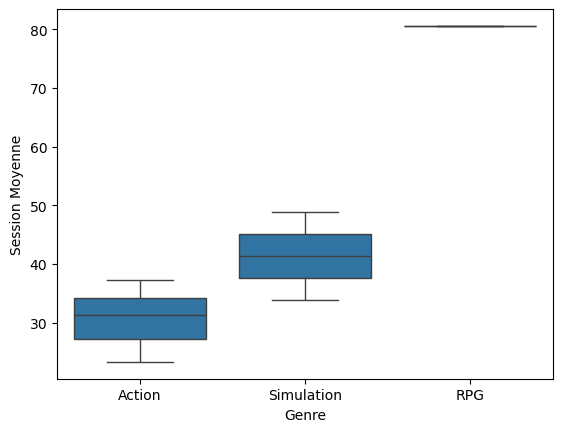

In [6]:
import seaborn as sns 

sns.boxplot(x="Genre" , y="Session Moyenne" , data=df_games)

In [7]:
# Create the products dataset
np.random.seed(42)

df_prix = pd.DataFrame({
    'name': ['sony projector X1', 'laptop Dell XPS', 'epson projector P1', 'canon camera', 
             'optoma projector HD', 'laptop HP', 'benq projector', 'smart TV', 
             'projector LG short throw', 'headphones', 'samsung projector', 'tablet'],
    'promotion': np.random.choice([True, False], 12),
    'min_price': np.random.randint(100, 1000, 12),
    'max_price': np.random.randint(500, 2000, 12),
    'category': "electronics",
    'brand': ['Sony', 'Dell', 'Epson', 'Canon', 'Optoma', 'HP', 'BenQ', 'Samsung', 
              'LG', 'Sony', 'Samsung', 'Apple']
})

# Ensure max_price is greater than min_price
for i in range(len(df_prix)):
    if df_prix.loc[i, 'max_price'] <= df_prix.loc[i, 'min_price']:
        df_prix.loc[i, 'max_price'] = df_prix.loc[i, 'min_price'] + np.random.randint(100, 500)

print("\ndf_prix created!")
print(df_prix)


df_prix created!
                        name  promotion  min_price  max_price     category  \
0          sony projector X1       True        430       1937  electronics   
1            laptop Dell XPS      False        558       1305  electronics   
2         epson projector P1       True        187        885  electronics   
3               canon camera       True        472       1715  electronics   
4        optoma projector HD       True        199       1455  electronics   
5                  laptop HP      False        971       1415  electronics   
6             benq projector       True        763       1684  electronics   
7                   smart TV       True        230        959  electronics   
8   projector LG short throw       True        761       1837  electronics   
9                 headphones      False        408        521  electronics   
10         samsung projector       True        869       1017  electronics   
11                    tablet       True       

In [9]:
df_prix["price"]=0
def sol(ligne):
  if ligne["promotion"]=="On Sale" :
    ligne["price"]=ligne["min_price"]
  else :
    ligne["price"]=ligne["max_price"]
  return ligne
df_prix=df_prix.apply(sol)

KeyError: 'promotion'